In [69]:
# Importation des modules nécessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from scipy.optimize import curve_fit

In [14]:
# Chargement des mesures en fonction de leur position
data1 = pd.read_excel('imagerie_T.xlsx','x=12mm').dropna()
data2 = pd.read_excel('imagerie_T.xlsx','x=23mm').dropna()
data3 = pd.read_excel('imagerie_T.xlsx','x=32,5mm').dropna()
data4 = pd.read_excel('imagerie_T.xlsx','x=43mm').dropna()
data5 = pd.read_excel('imagerie_T.xlsx','x=53,5mm').dropna()
data6 = pd.read_excel('imagerie_T.xlsx','x=62,5mm').dropna()
data7 = pd.read_excel('imagerie_T.xlsx','x=72mm').dropna()
# Enregistrement des données dans une liste 
data = [data1,data2,data3,data4,data5,data6,data7]
table_x = [0.012,0.023,0.0325,0.043,0.0535,0.0625,0.072]

In [10]:
# Vérification des données chargées
#print(data1)
#print(data2)
#print(data3)
#print(data4)
#print(data5)
#print(data6)
#print(data7)

In [11]:
# Définition des fonctions à ajuster
# x = 12 mm
def function_for_fit1(t,alpha,c0): #eqn. 52, avec x = 12 mm
    return c0/(np.sqrt(4*np.pi*alpha*t) ) * np.exp( -0.012**2/(4*alpha*t) )
# x = 23 mm
def function_for_fit2(t,alpha,c0): #eqn. 52, avec x = 23 mm
    return c0/(np.sqrt(4*np.pi*alpha*t) ) * np.exp( -0.023**2/(4*alpha*t) )
# x = 32,5 mm
def function_for_fit3(t,alpha,c0): #eqn. 52, avec x = 32,5 mm
    return c0/(np.sqrt(4*np.pi*alpha*t) ) * np.exp( -0.0325**2/(4*alpha*t) )
# x = 43 mm
def function_for_fit4(t,alpha,c0): #eqn. 52, avec x = 43 mm
    return c0/(np.sqrt(4*np.pi*alpha*t) ) * np.exp( -0.043**2/(4*alpha*t) )
# x = 53,5 mm
def function_for_fit5(t,alpha,c0): #eqn. 52, avec x = 53,5 mm
    return c0/(np.sqrt(4*np.pi*alpha*t) ) * np.exp( -0.0535**2/(4*alpha*t) )
# x = 62,5 mm
def function_for_fit6(t,alpha,c0): #eqn. 52, avec x = 62,5 mm
    return c0/(np.sqrt(4*np.pi*alpha*t) ) * np.exp( -0.0625**2/(4*alpha*t) )
# x = 72 mm
def function_for_fit7(t,alpha,c0): #eqn. 52, avec x = 72 mm
    return c0/(np.sqrt(4*np.pi*alpha*t) ) * np.exp( -0.072**2/(4*alpha*t) )

lst_fit_functions = [function_for_fit1, function_for_fit2, function_for_fit3, function_for_fit4, function_for_fit5, function_for_fit6, function_for_fit7]

In [80]:
# Définition de la fonction de calcul d'alpha pour chaque position
def calcul_alpha_c0(table, function_for_fit, lst_alpha, lst_sigma_alpha, lst_c0, lst_sigma_c0, x):

    deltaT_complet = table['delta T (degC)'] # deltaT = T - T0
    temps_complet = table['temps (s)']

    # On retire la première valeur
    deltaT = deltaT_complet[1:]
    temps = temps_complet[1:]
    
    # Calcul des paramètres optimaux
    popt, pcov = curve_fit(function_for_fit, temps, deltaT)

    # Récupération des valeurs
    alpha_fit = popt[0]
    alpha_ecart_type = np.sqrt(pcov[0,0])
    c0_fit = popt[1]
    c0_ecart_type = np.sqrt(pcov[1,1])
    lst_alpha.append(alpha_fit)
    lst_sigma_alpha.append(alpha_ecart_type)
    lst_c0.append(c0_fit)
    lst_sigma_c0.append(c0_ecart_type)

    # Affichage du graphique
    timeforgraph = np.arange(800)[1:]
    fig, ax = plt.subplots(1,1,figsize=(8,6))
    ax.set_title(f'Différence de température en fonction du temps pour x = {x} m')
    ax.errorbar(temps,deltaT,xerr=[1],yerr=[4],c='gray',linestyle='none',capsize=3)
    ax.plot(temps,deltaT,'kx', label = 'ΔT')
    ax.plot(function_for_fit(timeforgraph,alpha_fit,c0_fit),'b', label = 'Fonction d\'ajustement')
    ax.set_xlabel('Temps [s]')
    ax.set_ylabel('Δ température [°C]')
    ax.grid()
    ax.legend(loc = 4)
    plt.savefig(f'Figures/x={x}m.pdf')

/opt/jlab-env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/jlab-env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/jlab-env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/jlab-env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/jlab-env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/jlab-env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sq

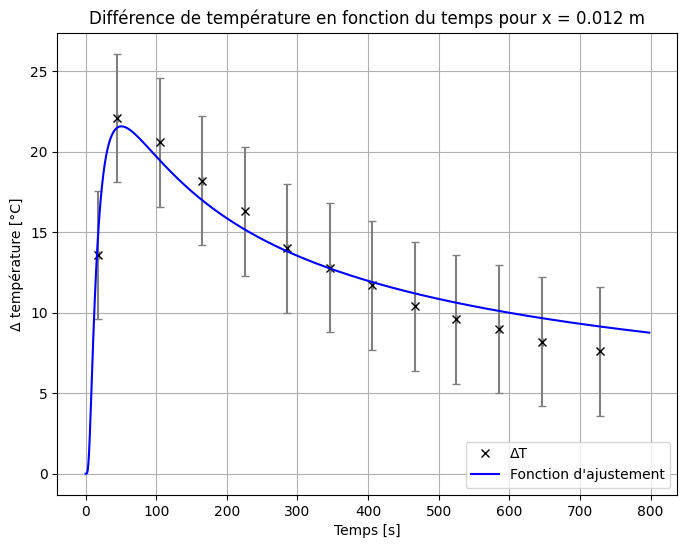

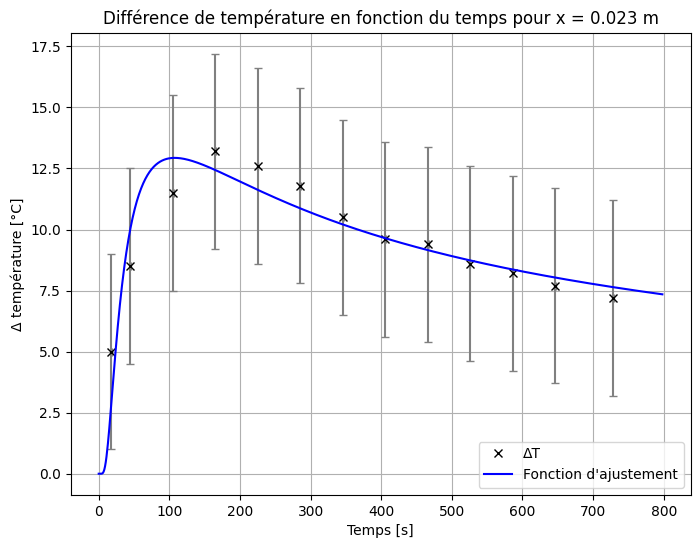

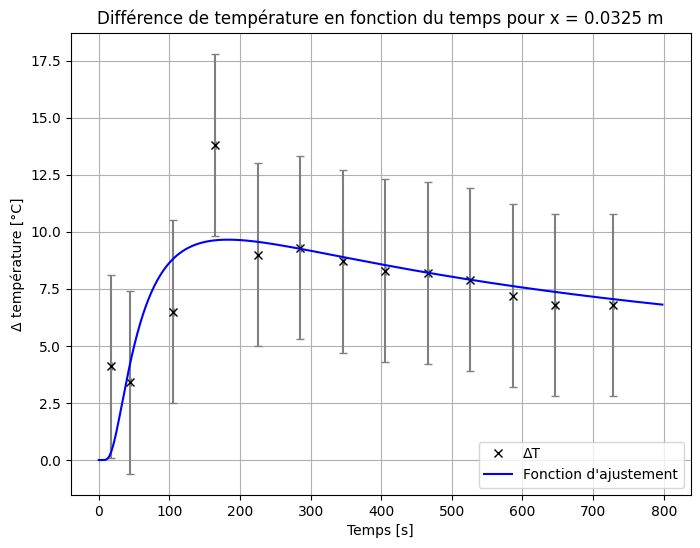

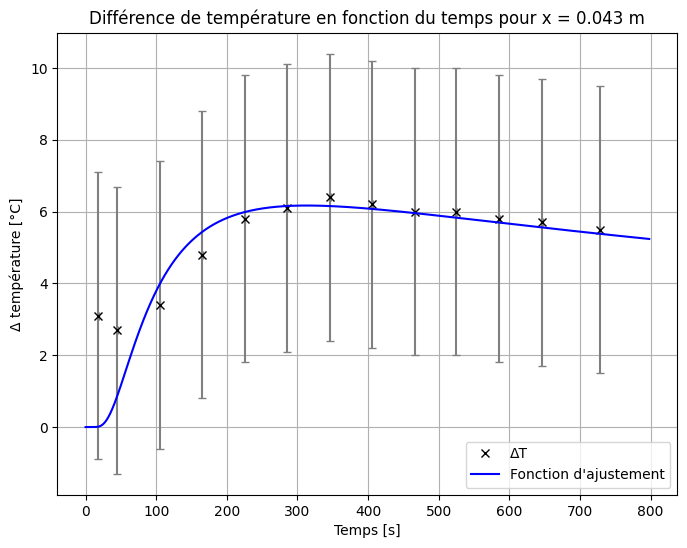

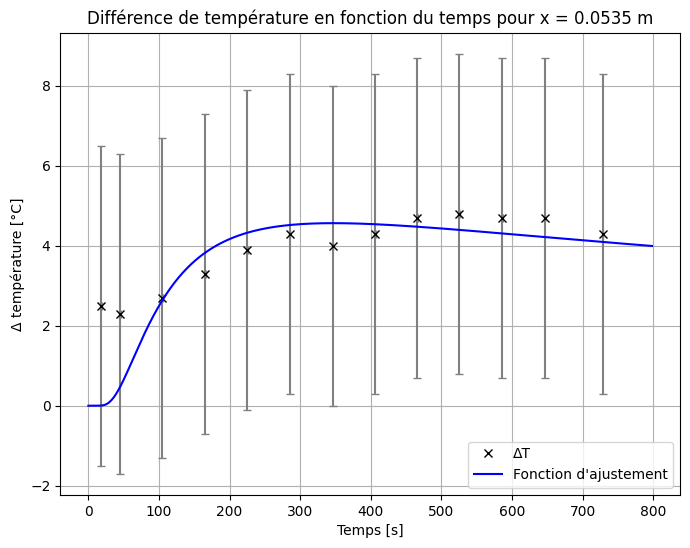

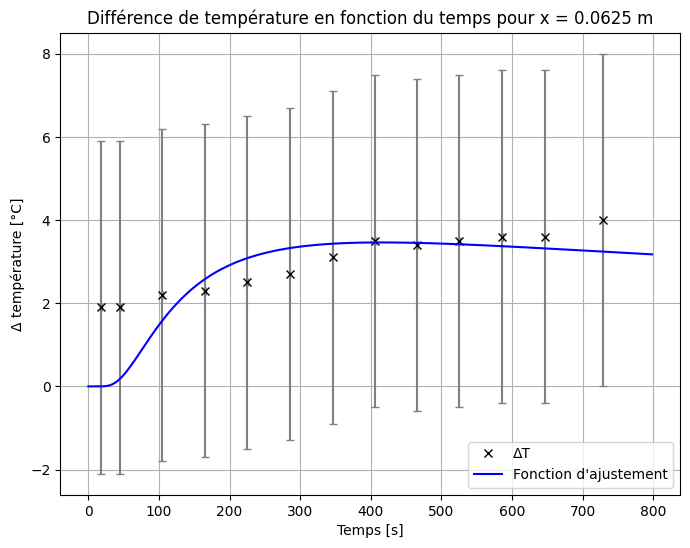

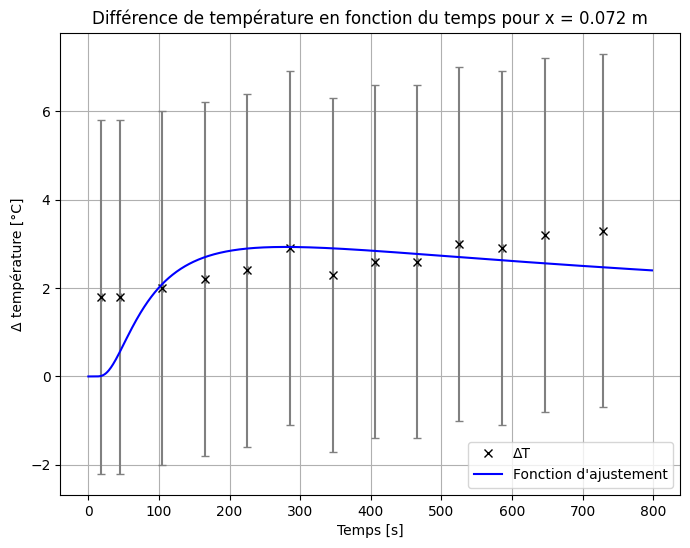

In [81]:
# Définition des listes de sortie
liste_alpha = []
liste_sigma_alpha = []
liste_c0 = []
liste_sigma_c0 = []

# Appel de la fonction calcul alpha c0 pour chaque x
for i in range(len(data)):
    calcul_alpha_c0(data[i], lst_fit_functions[i], liste_alpha, liste_sigma_alpha, liste_c0, liste_sigma_c0, table_x[i])

In [44]:
# Calcul de la moyenne pondérée

def moyenne_ponderee(x,sigma):
    w = []
    for i in range(len(sigma)):
        w.append(1/sigma[i]**2)

    # Calcul des xiwi
    wx = []
    for i in range(len(x)):
        wx.append(x[i]*w[i])

    # Calcul de la moyenne pondérée
    mean = sum(wx)/sum(w)

    # Calcul de l'écart à la moyenne de xi
    ecart_moy = []
    for i in range(len(x)):
        ecart_moy.append(w[i]*(x[i]-mean)**2)

    # Calcul sigma
    sigma_x = np.sqrt(sum(ecart_moy)/sum(w))

    return mean, 2*sigma_x

In [46]:
# Calcul de alpha moyen et de son erreur

mean_alpha, sigma_alpha = moyenne_ponderee(liste_alpha, liste_sigma_alpha)
print(f'alpha = {mean_alpha} +/- {sigma_alpha}')

# Calcul de c0 moyen et de son erreur

mean_c0, sigma_c0 = moyenne_ponderee(liste_c0, liste_sigma_c0)
print(f'c0 = {mean_c0} +/- {sigma_c0}')

alpha = 1.591791673709197e-06 +/- 1.069503440653381e-06
c0 = 1.0867908977041674 +/- 0.2054375044289176


In [47]:
# Calcul de la conductivité thermique k

Cv = 1.27e6
k = mean_alpha * Cv
k_error = k*np.sqrt((sigma_alpha/mean_alpha)**2+(0.01e6/Cv)**2)
print(f'k = {k} +/- {k_error}')

k = 2.0215754256106804 +/- 1.3583626395582906


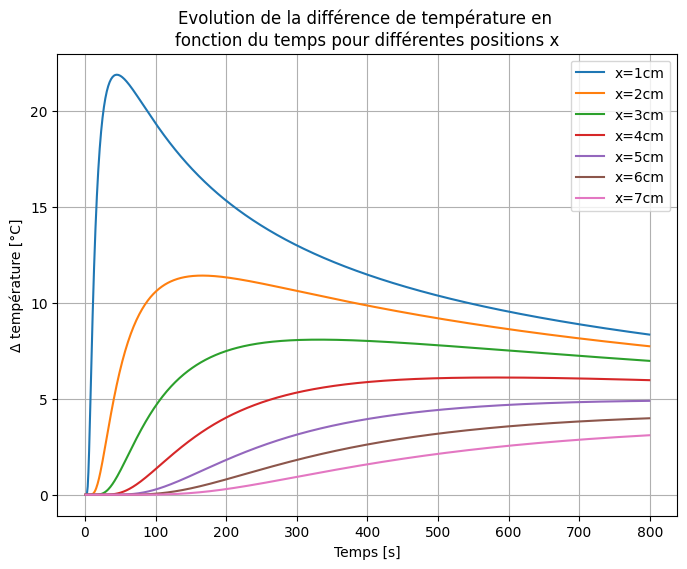

In [83]:
def chaleur1d(t,x,alpha,c0):
    return (c0/np.sqrt(4*np.pi*alpha*t))*np.exp((-x**2)/(4*alpha*t))

# Affichage graphique final

time = np.arange(1,800)
plt.figure(figsize=(8,6))
for x in table_x:#np.arange(0.01,0.1,0.01):
    T = chaleur1d(time,x,mean_alpha,mean_c0)
    plt.plot(time,T,label={'x='+str(round(x*100))+'cm'})
plt.xlabel('Temps [s]')
plt.ylabel('Δ température [°C]')
plt.legend(loc=1)
plt.title('Evolution de la différence de température en \nfonction du temps pour différentes positions x')
plt.grid()
plt.savefig(f'Figures/figure_finale.pdf')